In [12]:
selected_backbone = "efficientnet_b0"


In [13]:
# Imports, reproducibility, and dataset statistics

import os
import random
from pathlib import Path
import numpy as np

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, Subset
    from torchvision import datasets, transforms, models
except ImportError as exc:
    raise ImportError(
        "PyTorch and torchvision are required. Install them in your notebook environment before running this notebook."
    ) from exc

import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, f1_score

SEED = 42
DATA_DIR = "lavender_dataset_splitted_stress"

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

def compute_dataset_mean_std(data_dir, img_size=224, batch_size=8):
    dataset = datasets.ImageFolder(
        root=data_dir,
        transform=transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
        ]),
    )
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    mean = torch.zeros(3)
    std = torch.zeros(3)
    total = 0

    for images, _ in loader:
        b = images.size(0)
        images = images.view(b, images.size(1), -1)
        mean += images.mean(2).sum(0)
        std += images.std(2).sum(0)
        total += b

    mean /= total
    std /= total
    return mean, std, dataset.classes, len(dataset)

if not os.path.isdir(DATA_DIR):
    raise SystemExit(f"Dataset directory not found: {DATA_DIR}")

mean, std, class_names, dataset_size = compute_dataset_mean_std(DATA_DIR, img_size=224)
print(f"Dataset size: {dataset_size}")
print(f"Classes: {class_names}")
print(f"Dataset mean: {mean}")
print(f"Dataset std: {std}")

# ImageNet statistics are used for pretrained transfer learning transforms.
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
print(f"ImageNet normalization: mean={IMAGENET_MEAN}, std={IMAGENET_STD}")


Dataset size: 118
Classes: ['not_stressed', 'stressed']
Dataset mean: tensor([0.2229, 0.2028, 0.1973])
Dataset std: tensor([0.1884, 0.1824, 0.1612])
ImageNet normalization: mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)


In [14]:
# Transfer-learning model, freezing policy, loaders, and train/eval utilities

if "selected_backbone" not in globals():
    selected_backbone = "efficientnet_b0"


def build_model(num_classes, use_imagenet=True):
    weights = models.EfficientNet_B0_Weights.DEFAULT if use_imagenet and hasattr(models, "EfficientNet_B0_Weights") else None
    model = models.efficientnet_b0(weights=weights)
    in_features = model.classifier[-1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, num_classes),
    )
    return model


def freeze_backbone(model):
    for p in model.parameters(): # Freeze all parameters by default
        p.requires_grad = False
    
    for p in model.classifier.parameters(): # Always unfreeze the head
        p.requires_grad = True


def unfreeze_last_blocks(model):
    for p in model.features[-1].parameters(): # Unfreeze the last block of the backbone
        p.requires_grad = True
    for p in model.classifier.parameters(): # Ensure the head is also unfrozen
        p.requires_grad = True


def build_stage2_param_groups(model, backbone_lr, head_lr):
    backbone_params = [p for p in model.features[-1].parameters() if p.requires_grad]
    head_params = [p for p in model.classifier.parameters() if p.requires_grad]

    groups = []
    if backbone_params:
        groups.append({"params": backbone_params, "lr": backbone_lr})
    if head_params:
        groups.append({"params": head_params, "lr": head_lr})
    return groups


def get_loaders_kfold(
    data_dir,
    batch_size=16,
    img_size=224,
    n_splits=5,
    seed=42,
    mean=IMAGENET_MEAN, # Use ImageNet stats for pretrained models, or dataset stats for training from scratch
    std=IMAGENET_STD,
):
    train_transform = transforms.Compose([ # Data augmentation for training
        transforms.RandomResizedCrop(img_size, scale=(0.75, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=20),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
        transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),
    ])

    val_transform = transforms.Compose([ 
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])

    full_dataset = datasets.ImageFolder(root=data_dir, transform=train_transform)
    labels = full_dataset.targets 
    classes = full_dataset.classes 
    n_samples = len(full_dataset)

    splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    splits = list(splitter.split(np.arange(n_samples), labels))

    fold_loaders = []
    for train_idx, val_idx in splits:
        train_dataset = datasets.ImageFolder(root=data_dir, transform=train_transform)
        val_dataset = datasets.ImageFolder(root=data_dir, transform=val_transform)

        train_subset = Subset(train_dataset, train_idx)
        val_subset = Subset(val_dataset, val_idx)

        train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=False)
        val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)

        fold_loaders.append((train_loader, val_loader))

    return fold_loaders, len(classes), classes


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device, return_predictions=False):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            if return_predictions:
                all_labels.extend(labels.cpu().numpy().tolist())
                all_preds.extend(preds.cpu().numpy().tolist())

    avg_loss = running_loss / total
    avg_acc = correct / total

    if return_predictions:
        return avg_loss, avg_acc, all_labels, all_preds
    return avg_loss, avg_acc


def save_checkpoint(path, model, optimizer, fold_idx, epoch, backbone, num_classes, val_loss, val_acc, stage):
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "fold": fold_idx,
            "epoch": epoch,
            "backbone": backbone,
            "num_classes": num_classes,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "stage": stage,
        },
        path,
    )


def plot_loss_curves(train_losses, val_losses, fold_idx):
    plt.figure(figsize=(10, 5))
    epochs = range(1, len(train_losses) + 1)
    plt.plot(epochs, train_losses, "b-o", label="Train Loss", linewidth=2, markersize=5)
    plt.plot(epochs, val_losses, "r-o", label="Val Loss", linewidth=2, markersize=5)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Fold {fold_idx} - Training/Validation Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()



Fold 1/5 | backbone=efficientnet_b0 | ImageNet=True
[Stage1][Epoch 1/5] train_loss=0.7086 train_acc=0.4894 | val_loss=0.6524 val_acc=0.5833
[Stage1][Epoch 2/5] train_loss=0.6671 train_acc=0.5638 | val_loss=0.6240 val_acc=0.7083
[Stage1][Epoch 3/5] train_loss=0.6554 train_acc=0.6702 | val_loss=0.6322 val_acc=0.6667
[Stage1][Epoch 4/5] train_loss=0.6614 train_acc=0.6170 | val_loss=0.6362 val_acc=0.6250
[Stage1][Epoch 5/5] train_loss=0.6512 train_acc=0.6277 | val_loss=0.6350 val_acc=0.6250


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:61: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


[Stage2][Epoch 1/20] train_loss=0.6529 train_acc=0.6170 | val_loss=0.6244 val_acc=0.5833 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 2/20] train_loss=0.6141 train_acc=0.6702 | val_loss=0.6356 val_acc=0.5833 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 3/20] train_loss=0.5649 train_acc=0.7021 | val_loss=0.6241 val_acc=0.6667 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 4/20] train_loss=0.5638 train_acc=0.7021 | val_loss=0.6161 val_acc=0.6667 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 5/20] train_loss=0.5537 train_acc=0.7660 | val_loss=0.6116 val_acc=0.6250 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 6/20] train_loss=0.5650 train_acc=0.7021 | val_loss=0.6132 val_acc=0.6250 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 7/20] train_loss=0.5388 train_acc=0.7447 | val_loss=0.6121 val_acc=0.6667 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 8/20] train_loss=0.5621 train_acc=0.7234 | val_loss=0.6113 val_acc=0.6667 | group0=1.00e-04, group1=1.00e-03
[Stage2]

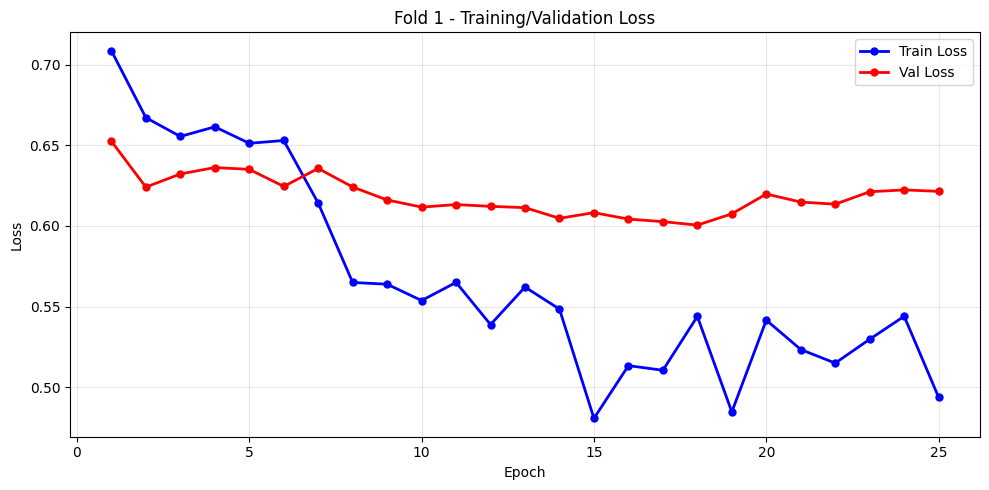

/var/folders/np/b2sgncvd6q71hxrmhl0lk75w0000gn/T/ipykernel_28704/3291088996.py:136: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_ckpt, map_loca

Fold 1 best-checkpoint test_loss=0.6005, test_acc=0.7500, macro_f1=0.7429
Confusion Matrix:
[[11  2]
 [ 4  7]]
Classification Report:
              precision    recall  f1-score   support

not_stressed     0.7333    0.8462    0.7857        13
    stressed     0.7778    0.6364    0.7000        11

    accuracy                         0.7500        24
   macro avg     0.7556    0.7413    0.7429        24
weighted avg     0.7537    0.7500    0.7464        24


Fold 2/5 | backbone=efficientnet_b0 | ImageNet=True
[Stage1][Epoch 1/5] train_loss=0.6985 train_acc=0.5106 | val_loss=0.7762 val_acc=0.5417
[Stage1][Epoch 2/5] train_loss=0.6663 train_acc=0.6064 | val_loss=0.7841 val_acc=0.5417
[Stage1][Epoch 3/5] train_loss=0.6721 train_acc=0.5745 | val_loss=0.7356 val_acc=0.5417
[Stage1][Epoch 4/5] train_loss=0.6381 train_acc=0.6277 | val_loss=0.7032 val_acc=0.5833
[Stage1][Epoch 5/5] train_loss=0.6344 train_acc=0.6702 | val_loss=0.7112 val_acc=0.5833


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:61: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


[Stage2][Epoch 1/20] train_loss=0.6383 train_acc=0.6809 | val_loss=0.7569 val_acc=0.5417 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 2/20] train_loss=0.6017 train_acc=0.6489 | val_loss=0.7660 val_acc=0.5417 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 3/20] train_loss=0.6347 train_acc=0.5851 | val_loss=0.7314 val_acc=0.5833 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 4/20] train_loss=0.6038 train_acc=0.6596 | val_loss=0.7399 val_acc=0.5417 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 5/20] train_loss=0.5407 train_acc=0.7766 | val_loss=0.7316 val_acc=0.6250 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 6/20] train_loss=0.6142 train_acc=0.6596 | val_loss=0.7489 val_acc=0.5417 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 7/20] train_loss=0.5348 train_acc=0.7660 | val_loss=0.7646 val_acc=0.5833 | group0=5.00e-05, group1=5.00e-04
Early stopping at epoch 7 (no improvement for 7 epochs)


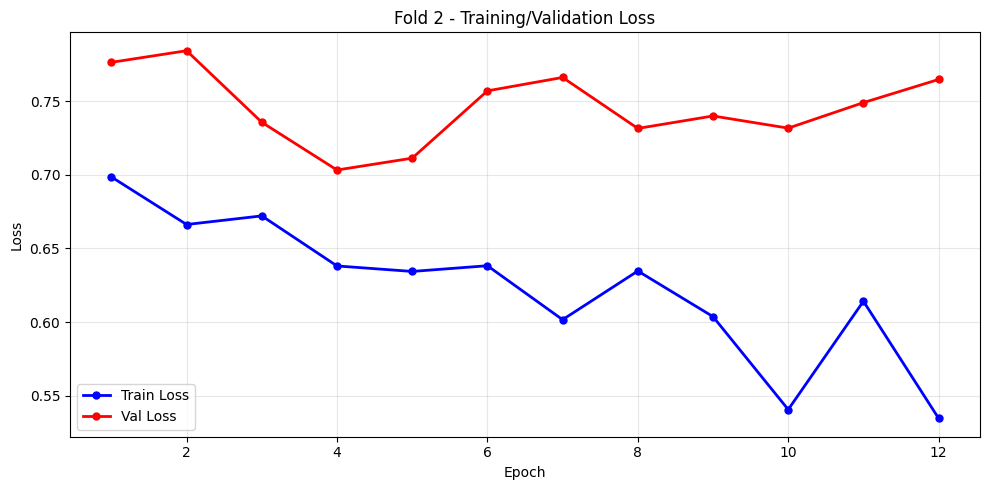

/var/folders/np/b2sgncvd6q71hxrmhl0lk75w0000gn/T/ipykernel_28704/3291088996.py:136: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_ckpt, map_loca

Fold 2 best-checkpoint test_loss=0.7032, test_acc=0.5833, macro_f1=0.4958
Confusion Matrix:
[[12  1]
 [ 9  2]]
Classification Report:
              precision    recall  f1-score   support

not_stressed     0.5714    0.9231    0.7059        13
    stressed     0.6667    0.1818    0.2857        11

    accuracy                         0.5833        24
   macro avg     0.6190    0.5524    0.4958        24
weighted avg     0.6151    0.5833    0.5133        24


Fold 3/5 | backbone=efficientnet_b0 | ImageNet=True
[Stage1][Epoch 1/5] train_loss=0.6919 train_acc=0.5745 | val_loss=0.7091 val_acc=0.4167
[Stage1][Epoch 2/5] train_loss=0.6779 train_acc=0.5638 | val_loss=0.6947 val_acc=0.5000
[Stage1][Epoch 3/5] train_loss=0.6643 train_acc=0.6383 | val_loss=0.6758 val_acc=0.6250
[Stage1][Epoch 4/5] train_loss=0.6227 train_acc=0.6383 | val_loss=0.6563 val_acc=0.6250
[Stage1][Epoch 5/5] train_loss=0.6742 train_acc=0.5745 | val_loss=0.6455 val_acc=0.7083


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:61: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


[Stage2][Epoch 1/20] train_loss=0.6612 train_acc=0.6170 | val_loss=0.6487 val_acc=0.6667 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 2/20] train_loss=0.6395 train_acc=0.6596 | val_loss=0.6407 val_acc=0.7500 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 3/20] train_loss=0.5587 train_acc=0.7553 | val_loss=0.6199 val_acc=0.6667 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 4/20] train_loss=0.6335 train_acc=0.6277 | val_loss=0.6308 val_acc=0.6250 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 5/20] train_loss=0.5710 train_acc=0.7128 | val_loss=0.6374 val_acc=0.5833 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 6/20] train_loss=0.6089 train_acc=0.6277 | val_loss=0.6466 val_acc=0.5833 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 7/20] train_loss=0.5567 train_acc=0.6809 | val_loss=0.6630 val_acc=0.5833 | group0=5.00e-05, group1=5.00e-04
[Stage2][Epoch 8/20] train_loss=0.5974 train_acc=0.6596 | val_loss=0.6652 val_acc=0.5833 | group0=5.00e-05, group1=5.00e-04
[Stage2]

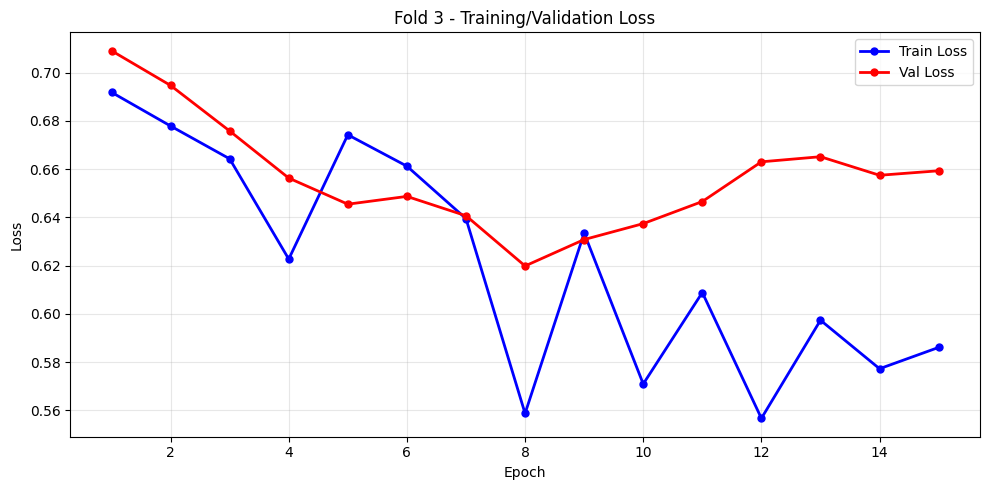

/var/folders/np/b2sgncvd6q71hxrmhl0lk75w0000gn/T/ipykernel_28704/3291088996.py:136: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_ckpt, map_loca

Fold 3 best-checkpoint test_loss=0.6199, test_acc=0.6667, macro_f1=0.5966
Confusion Matrix:
[[13  0]
 [ 8  3]]
Classification Report:
              precision    recall  f1-score   support

not_stressed     0.6190    1.0000    0.7647        13
    stressed     1.0000    0.2727    0.4286        11

    accuracy                         0.6667        24
   macro avg     0.8095    0.6364    0.5966        24
weighted avg     0.7937    0.6667    0.6106        24


Fold 4/5 | backbone=efficientnet_b0 | ImageNet=True
[Stage1][Epoch 1/5] train_loss=0.7506 train_acc=0.4632 | val_loss=0.7042 val_acc=0.5217
[Stage1][Epoch 2/5] train_loss=0.6637 train_acc=0.6316 | val_loss=0.7169 val_acc=0.5217
[Stage1][Epoch 3/5] train_loss=0.6641 train_acc=0.6316 | val_loss=0.7202 val_acc=0.5652
[Stage1][Epoch 4/5] train_loss=0.6337 train_acc=0.5789 | val_loss=0.7279 val_acc=0.5217
[Stage1][Epoch 5/5] train_loss=0.6498 train_acc=0.6000 | val_loss=0.7291 val_acc=0.5217


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:61: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


[Stage2][Epoch 1/20] train_loss=0.6343 train_acc=0.6316 | val_loss=0.7023 val_acc=0.5652 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 2/20] train_loss=0.6470 train_acc=0.6526 | val_loss=0.7006 val_acc=0.5217 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 3/20] train_loss=0.5756 train_acc=0.7579 | val_loss=0.6779 val_acc=0.5652 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 4/20] train_loss=0.6176 train_acc=0.6526 | val_loss=0.6793 val_acc=0.5217 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 5/20] train_loss=0.5745 train_acc=0.7474 | val_loss=0.6573 val_acc=0.5652 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 6/20] train_loss=0.5590 train_acc=0.6737 | val_loss=0.6408 val_acc=0.6522 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 7/20] train_loss=0.5848 train_acc=0.6947 | val_loss=0.6485 val_acc=0.5652 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 8/20] train_loss=0.5677 train_acc=0.7158 | val_loss=0.6771 val_acc=0.5652 | group0=1.00e-04, group1=1.00e-03
[Stage2]

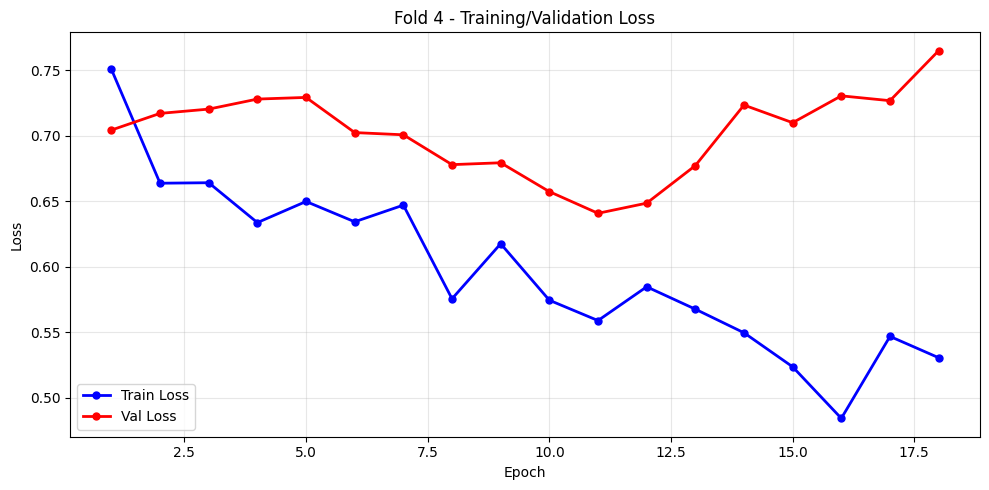

/var/folders/np/b2sgncvd6q71hxrmhl0lk75w0000gn/T/ipykernel_28704/3291088996.py:136: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_ckpt, map_loca

Fold 4 best-checkpoint test_loss=0.6408, test_acc=0.6522, macro_f1=0.6167
Confusion Matrix:
[[11  1]
 [ 7  4]]
Classification Report:
              precision    recall  f1-score   support

not_stressed     0.6111    0.9167    0.7333        12
    stressed     0.8000    0.3636    0.5000        11

    accuracy                         0.6522        23
   macro avg     0.7056    0.6402    0.6167        23
weighted avg     0.7014    0.6522    0.6217        23


Fold 5/5 | backbone=efficientnet_b0 | ImageNet=True
[Stage1][Epoch 1/5] train_loss=0.6865 train_acc=0.5789 | val_loss=0.6940 val_acc=0.4348
[Stage1][Epoch 2/5] train_loss=0.6885 train_acc=0.5263 | val_loss=0.6964 val_acc=0.5217
[Stage1][Epoch 3/5] train_loss=0.6686 train_acc=0.6632 | val_loss=0.6878 val_acc=0.4783
[Stage1][Epoch 4/5] train_loss=0.6657 train_acc=0.6316 | val_loss=0.6692 val_acc=0.5217
[Stage1][Epoch 5/5] train_loss=0.6446 train_acc=0.6421 | val_loss=0.6474 val_acc=0.5652


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:61: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


[Stage2][Epoch 1/20] train_loss=0.6085 train_acc=0.6737 | val_loss=0.6272 val_acc=0.7391 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 2/20] train_loss=0.6386 train_acc=0.6526 | val_loss=0.6246 val_acc=0.7391 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 3/20] train_loss=0.6212 train_acc=0.6526 | val_loss=0.6051 val_acc=0.7391 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 4/20] train_loss=0.5685 train_acc=0.7579 | val_loss=0.5858 val_acc=0.7826 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 5/20] train_loss=0.6231 train_acc=0.7053 | val_loss=0.5746 val_acc=0.8261 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 6/20] train_loss=0.6240 train_acc=0.6526 | val_loss=0.5717 val_acc=0.8261 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 7/20] train_loss=0.5846 train_acc=0.6842 | val_loss=0.5657 val_acc=0.8261 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 8/20] train_loss=0.6157 train_acc=0.6842 | val_loss=0.5604 val_acc=0.7826 | group0=1.00e-04, group1=1.00e-03
[Stage2]

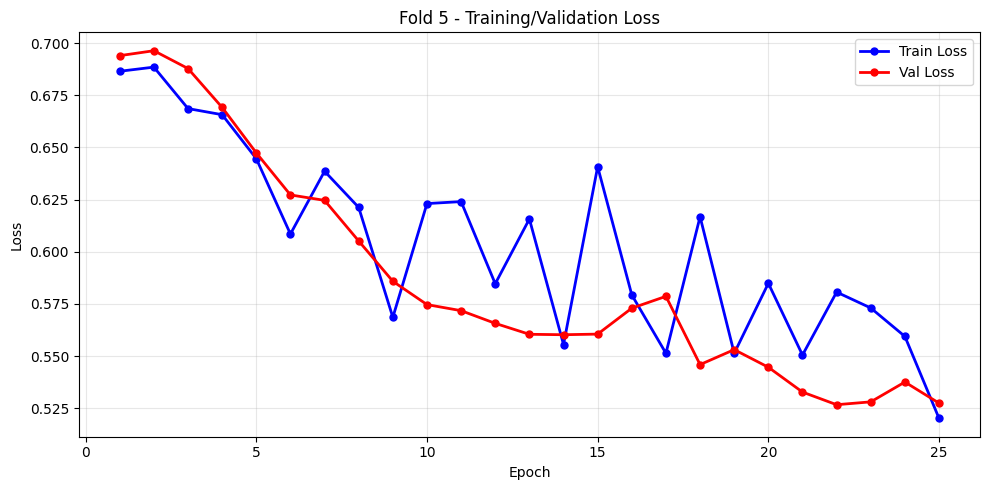

/var/folders/np/b2sgncvd6q71hxrmhl0lk75w0000gn/T/ipykernel_28704/3291088996.py:136: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_ckpt, map_loca

Fold 5 best-checkpoint test_loss=0.5267, test_acc=0.7391, macro_f1=0.7386
Confusion Matrix:
[[9 3]
 [3 8]]
Classification Report:
              precision    recall  f1-score   support

not_stressed     0.7500    0.7500    0.7500        12
    stressed     0.7273    0.7273    0.7273        11

    accuracy                         0.7391        23
   macro avg     0.7386    0.7386    0.7386        23
weighted avg     0.7391    0.7391    0.7391        23


Cross-Validation Summary
Fold 1: acc=0.7500, macro_f1=0.7429
Fold 2: acc=0.5833, macro_f1=0.4958
Fold 3: acc=0.6667, macro_f1=0.5966
Fold 4: acc=0.6522, macro_f1=0.6167
Fold 5: acc=0.7391, macro_f1=0.7386
Mean acc   : 0.6783 ± 0.0611
Mean macroF1: 0.6381 ± 0.0933


In [15]:
# Main training and testing loop (freeze then fine-tune)

import argparse


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--data-dir", type=str, default=DATA_DIR)
    parser.add_argument("--backbone", type=str, default=selected_backbone, choices=["efficientnet_b0"])
    parser.add_argument("--img-size", type=int, default=224)
    parser.add_argument("--batch-size", type=int, default=16)
    parser.add_argument("--n-splits", type=int, default=5)

    parser.add_argument("--stage1-epochs", type=int, default=5)
    parser.add_argument("--stage2-epochs", type=int, default=20)

    parser.add_argument("--head-lr", type=float, default=1e-3)
    parser.add_argument("--backbone-lr", type=float, default=1e-4)
    parser.add_argument("--weight-decay", type=float, default=1e-4)
    parser.add_argument("--early-stop-patience", type=int, default=7, help="Stop Stage 2 if val_loss does not improve for N epochs")

    parser.add_argument("--save-path", type=str, default="./models_weights_tl")
    parser.add_argument("--device", type=str, default="cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
    parser.add_argument("--no-imagenet", action="store_true", help="Disable ImageNet pretrained initialization")
    args = parser.parse_args([])

    if not os.path.isdir(args.data_dir):
        raise SystemExit(f"Dataset directory not found: {args.data_dir}")


    use_imagenet = not args.no_imagenet
    device = torch.device(args.device)

    fold_loaders, num_classes, classes = get_loaders_kfold(
        data_dir=args.data_dir,
        batch_size=args.batch_size,
        img_size=args.img_size,
        n_splits=args.n_splits,
        seed=SEED,
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD,
    )

    criterion = nn.CrossEntropyLoss()
    fold_results = []

    for fold_idx, (train_loader, val_loader) in enumerate(fold_loaders, start=1):
        print("\n" + "=" * 72)
        print(f"Fold {fold_idx}/{args.n_splits} | backbone={args.backbone} | ImageNet={use_imagenet}")
        print("=" * 72)

        model = build_model( num_classes=num_classes, use_imagenet=use_imagenet).to(device)

        train_losses, val_losses = [], []
        best_val_loss = float("inf")
        best_ckpt = f"{args.save_path}_{args.backbone}_fold{fold_idx}.pth"

        # Stage 1: train head only (backbone frozen)
        freeze_backbone(model)
        optimizer = optim.Adam([p for p in model.parameters() if p.requires_grad], lr=args.head_lr, weight_decay=args.weight_decay)

        for epoch in range(1, args.stage1_epochs + 1):
            train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
            val_loss, val_acc = evaluate(model, val_loader, criterion, device)

            train_losses.append(train_loss)
            val_losses.append(val_loss)

            print(
                f"[Stage1][Epoch {epoch}/{args.stage1_epochs}] "
                f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
                f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
            )

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                save_checkpoint(
                    path=best_ckpt,
                    model=model,
                    optimizer=optimizer,
                    fold_idx=fold_idx,
                    epoch=epoch,
                    backbone=args.backbone,
                    num_classes=num_classes,
                    val_loss=val_loss,
                    val_acc=val_acc,
                    stage="head-only",
                )

        # Stage 2: unfreeze last block(s) + head
        unfreeze_last_blocks(model)
        stage2_groups = build_stage2_param_groups(model, args.backbone_lr, args.head_lr)
        optimizer = optim.Adam(stage2_groups, weight_decay=args.weight_decay)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.5, verbose=True)

        es_counter = 0
        for epoch in range(1, args.stage2_epochs + 1):
            train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
            val_loss, val_acc = evaluate(model, val_loader, criterion, device)
            scheduler.step(val_loss)

            train_losses.append(train_loss)
            val_losses.append(val_loss)

            lr_info = ", ".join([f"group{i}={pg['lr']:.2e}" for i, pg in enumerate(optimizer.param_groups)])
            print(
                f"[Stage2][Epoch {epoch}/{args.stage2_epochs}] "
                f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
                f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | {lr_info}"
            )

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                es_counter = 0
                save_checkpoint(
                    path=best_ckpt,
                    model=model,
                    optimizer=optimizer,
                    fold_idx=fold_idx,
                    epoch=args.stage1_epochs + epoch,
                    backbone=args.backbone,
                    num_classes=num_classes,
                    val_loss=val_loss,
                    val_acc=val_acc,
                    stage="fine-tune",
                )
            else:
                es_counter += 1
                if es_counter >= args.early_stop_patience:
                    print(f"Early stopping at epoch {epoch} (no improvement for {args.early_stop_patience} epochs)")
                    break

        plot_loss_curves(train_losses, val_losses, fold_idx)

        # Testing on fold validation set using best checkpoint
        checkpoint = torch.load(best_ckpt, map_location=device)
        model.load_state_dict(checkpoint["model_state_dict"])

        test_loss, test_acc, y_true, y_pred = evaluate(
            model, val_loader, criterion, device, return_predictions=True
        )
        macro_f1 = f1_score(y_true, y_pred, average="macro")

        print(f"Fold {fold_idx} best-checkpoint test_loss={test_loss:.4f}, test_acc={test_acc:.4f}, macro_f1={macro_f1:.4f}")
        print("Confusion Matrix:")
        print(confusion_matrix(y_true, y_pred))
        print("Classification Report:")
        print(classification_report(y_true, y_pred, target_names=classes, digits=4))

        fold_results.append({"fold": fold_idx, "acc": test_acc, "macro_f1": macro_f1})

    # Aggregate summary
    accs = [r["acc"] for r in fold_results]
    f1s = [r["macro_f1"] for r in fold_results]

    print("\n" + "=" * 72)
    print("Cross-Validation Summary")
    print("=" * 72)
    for r in fold_results:
        print(f"Fold {r['fold']}: acc={r['acc']:.4f}, macro_f1={r['macro_f1']:.4f}")
    print(f"Mean acc   : {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"Mean macroF1: {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print("=" * 72)


main()
